In [1]:
# https://www.kaggle.com/datasets/janiobachmann/bank-marketing-dataset

# Load Data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv("47-bank-additional-full.csv", sep=';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Müşteri ile ilgili özellikler

- age → Müşterinin yaşı (sayısal).

- job → Müşterinin mesleği (categorical, örn: admin., technician, blue-collar vb).

- marital → Medeni durum (married, single, divorced).

- education → Eğitim seviyesi (primary, secondary, tertiary, unknown).

- default → Kredisi (borç) var mı? (yes/no/unknown).

- housing → Konut kredisi var mı? (yes/no/unknown).

- loan → Tüketici kredisi var mı? (yes/no/unknown).

### İletişim ile ilgili özellikler

- contact → Müşteriye hangi yolla ulaşıldı? (cellular, telephone, unknown).

- month → Son kampanya için iletişim ayı (jan, feb, mar … dec).

- day_of_week → Görüşmenin yapıldığı haftanın günü (mon, tue, …).

- duration → Görüşmenin süresi (saniye cinsinden). ⚠️ Çok önemli bir değişken, genellikle hedef değişkenle en güçlü ilişkili olanlardan biri.

### Kampanya ile ilgili özellikler

- campaign → Bu müşteriyle bu kampanyada kaç kere iletişim kuruldu?

- pdays → Müşteriyle önceki kampanyadan sonra kaç gün geçti?

- -1 değeri = daha önce hiç iletişim kurulmamış.

- previous → Bu müşteriyle önceki kampanyalarda kaç kez iletişim kuruldu?

- poutcome → Önceki kampanyanın sonucu (success, failure, nonexistent).

### Ekonomik göstergeler (makroekonomi)

- emp.var.rate → İstihdam değişim oranı (quarterly employment variation rate).

- cons.price.idx → Tüketici fiyat endeksi (CPI).

- cons.conf.idx → Tüketici güven endeksi (confidence index).

- euribor3m → 3 aylık Euribor faiz oranı.

- nr.employed → Çalışan kişi sayısı (ortalama).

In [6]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [8]:
df.duplicated().sum()

12

# EDA

In [9]:
df['job'].value_counts()

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [10]:
df['marital'].unique()

array(['married', 'single', 'divorced', 'unknown'], dtype=object)

In [11]:
df['contact'].value_counts()

contact
cellular     26144
telephone    15044
Name: count, dtype: int64

In [29]:
df['y'] = df['y'].replace(
    {
        'no' : 0,
        'yes': 1
    }
)

C:\Users\Ali İhsan Sancar\AppData\Local\Temp\ipykernel_9908\1992370747.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['y'] = df['y'].replace(


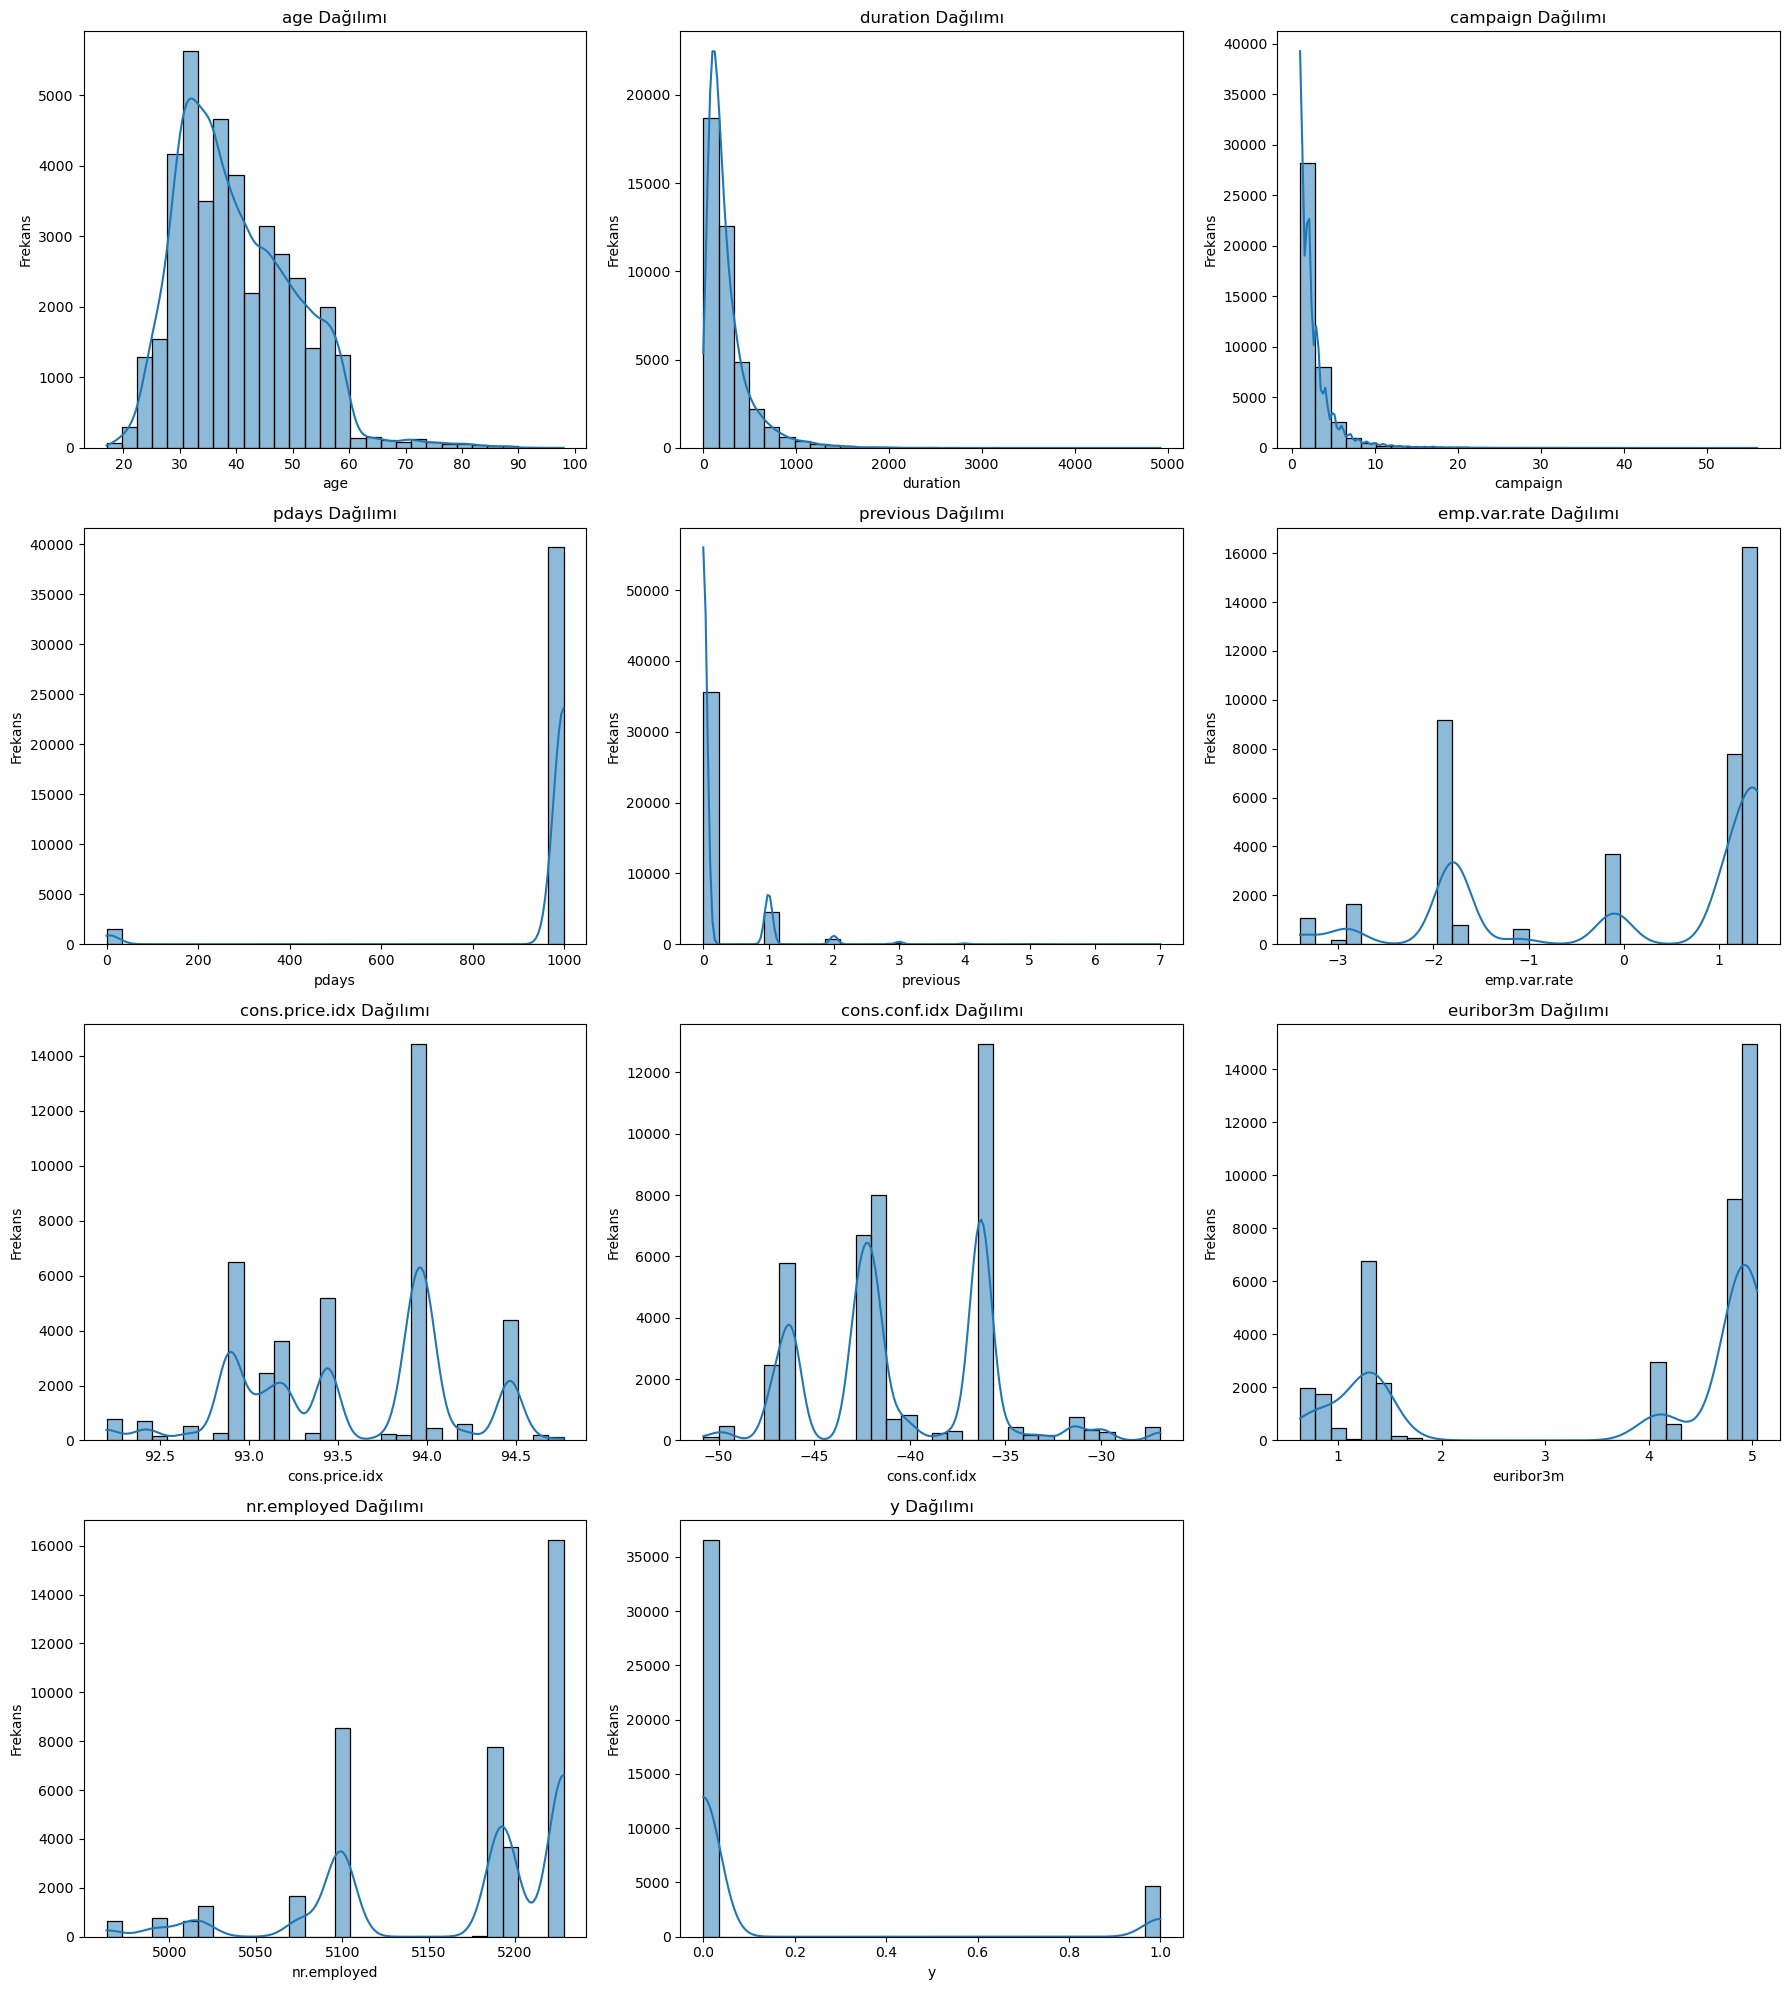

In [30]:
num_cols = [col for col in df.columns if df[col].dtype != 'O']

# Satır ve sütun sayısını otomatik hesapla
n_cols = 3  # her satırda 3 grafik olsun
n_rows = int(np.ceil(len(num_cols) / n_cols))

# Figure ayarı
fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()  # kolay indexleme için düzleştir

# Her numerik kolon için histogram çiz
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, bins=30, ax=axes[i])
    axes[i].set_title(f"{col} Dağılımı", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frekans")

# Kullanılmayan eksenleri kapat
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [31]:
def categorical_countplots(df):
    """
    DataFrame'deki kategorik sütunlar için otomatik countplot çizer.
    """
    cat_cols = [col for col in df.columns if df[col].dtype == 'O']
    
    n_cols = 3
    n_rows = int(np.ceil(len(cat_cols) / n_cols))
    fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(18, 5*n_rows))
    axes = axes.flatten()
    
    for i, col in enumerate(cat_cols):
        sns.countplot(data=df, x=col, ax=axes[i], color="skyblue")
        axes[i].set_title(f"{col} Countplot", fontsize=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frekans")
        axes[i].tick_params(axis='x', rotation=45)  # okunaklı olsun
    
    # Boş eksenleri kaldır
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

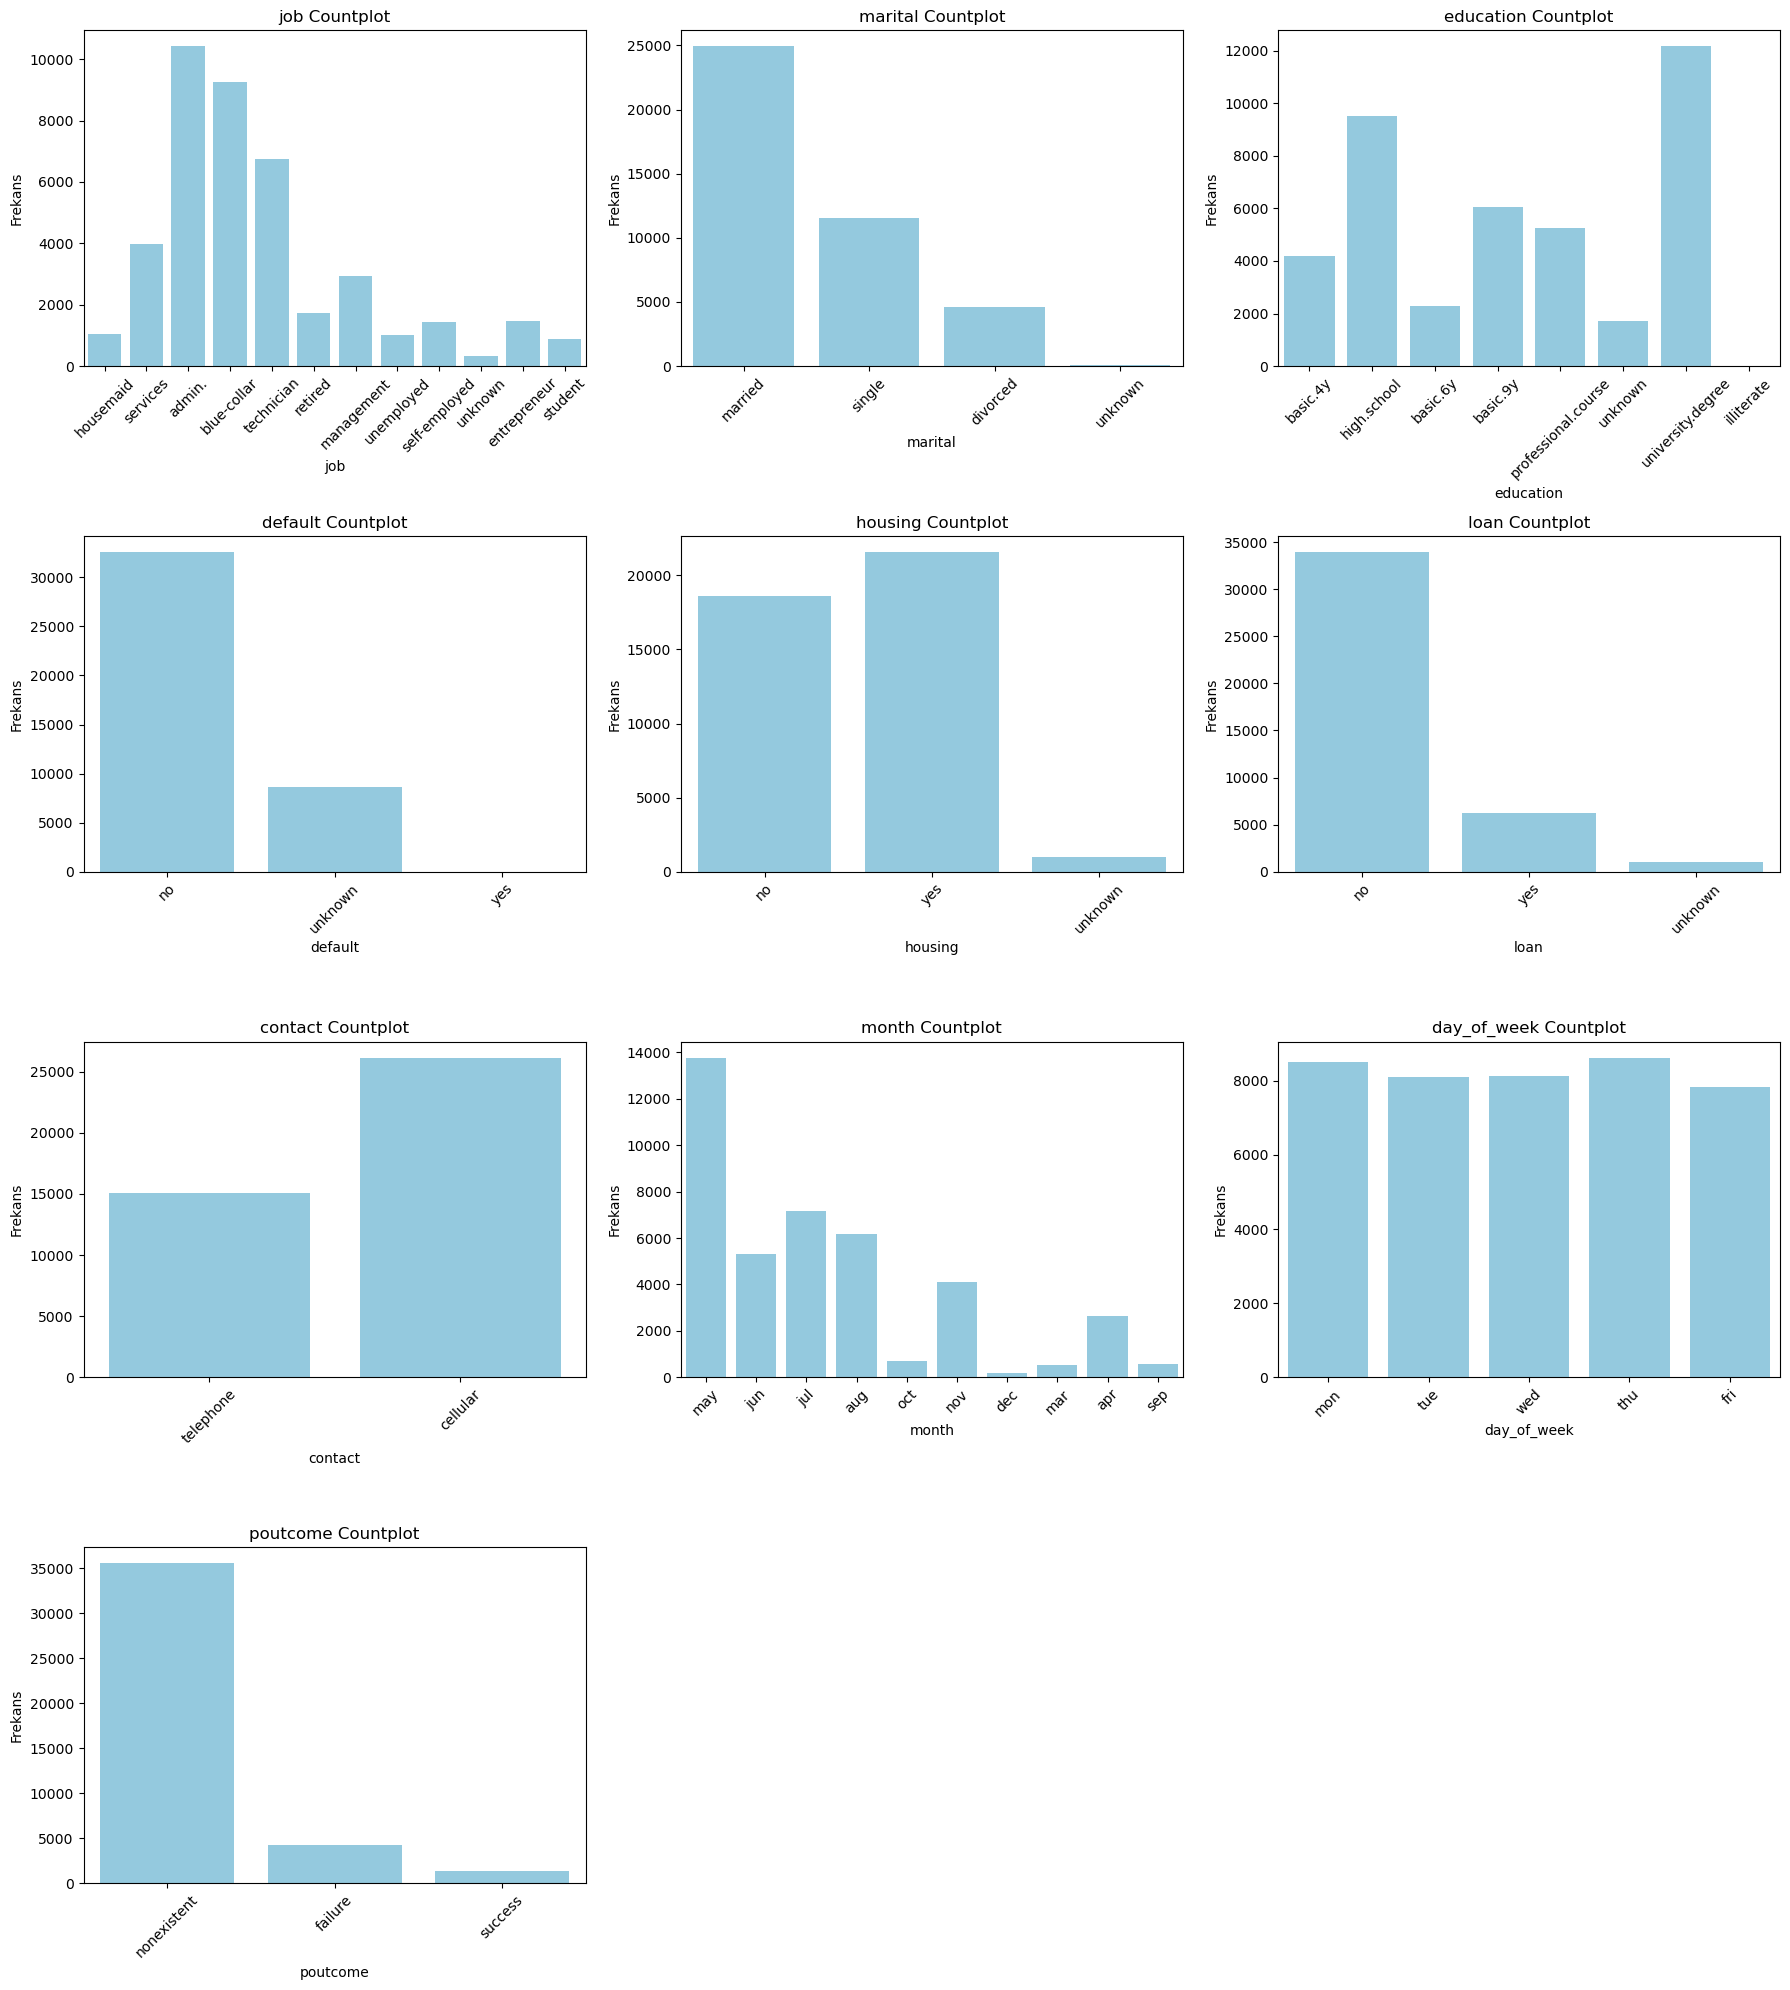

In [32]:
categorical_countplots(df)

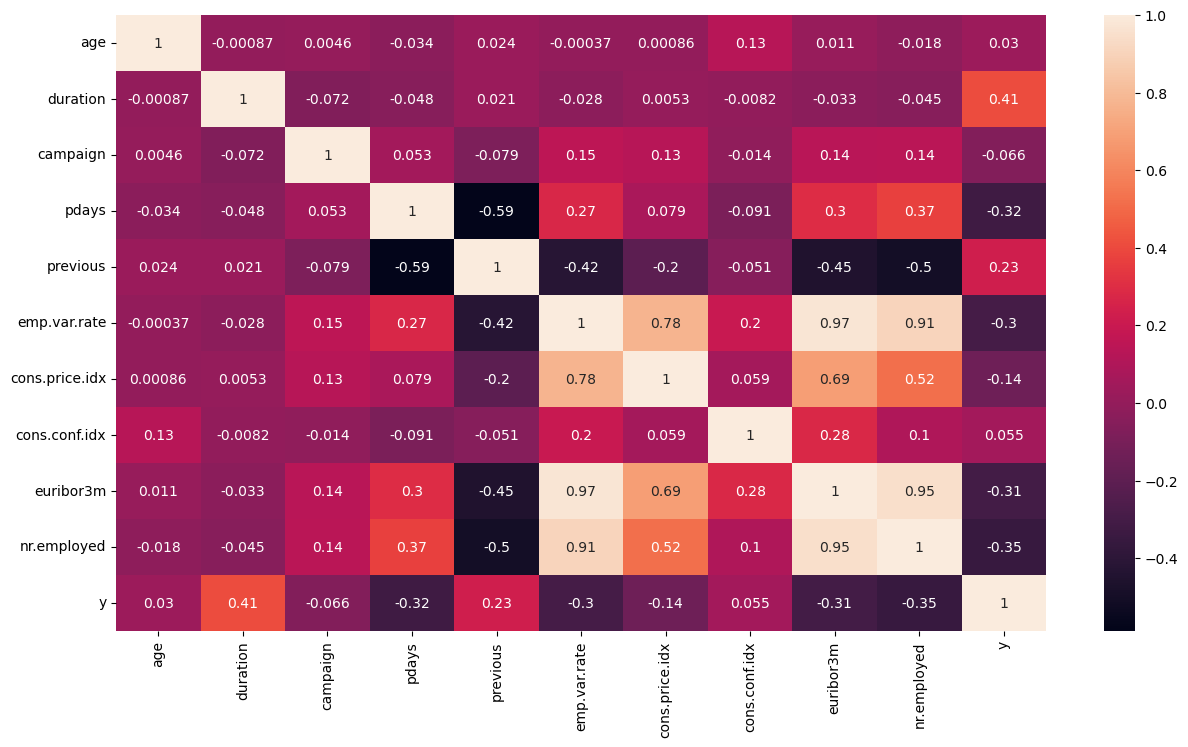

In [33]:
plt.figure(figsize=(15,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

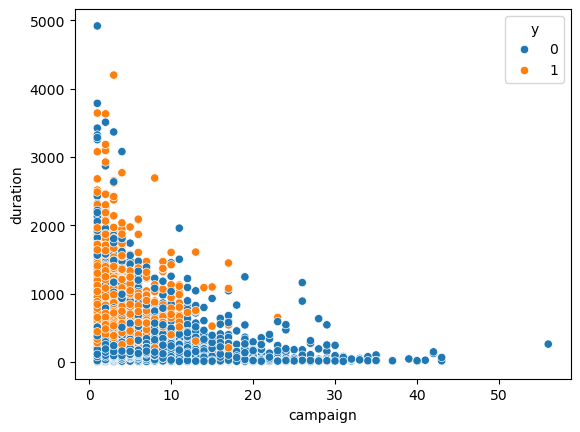

In [43]:
sns.scatterplot(df,x = 'campaign', y = 'duration', hue='y')
plt.show()

In [37]:
for col in [col for col in df.columns if df[col].dtype == 'O']:
    print(col, ":")
    print(df[col].unique())
    print("----------------")

job :
['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
----------------
marital :
['married' 'single' 'divorced' 'unknown']
----------------
education :
['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
----------------
default :
['no' 'unknown' 'yes']
----------------
housing :
['no' 'yes' 'unknown']
----------------
loan :
['no' 'yes' 'unknown']
----------------
contact :
['telephone' 'cellular']
----------------
month :
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
----------------
day_of_week :
['mon' 'tue' 'wed' 'thu' 'fri']
----------------
poutcome :
['nonexistent' 'failure' 'success']
----------------


In [82]:
columns_has_unkown = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Feature Engineering

### Outlier Analyse

In [56]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [45]:
def outlier_iqr_analyse(df,threshold):
    outliers_summary = {}
    numeric_columns = [col for col in df.columns if df[col].dtype != 'O']

    for col in numeric_columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outlier = df[ (df[col] < lower_bound) | (df[col] > upper_bound) ]

        outliers_summary[col] = {
            'outlier_shape' : outlier.shape[0],
            'outlier_percantage' : 100 * outlier.shape[0] / df.shape[0],
            'lower' : lower_bound,
            'upper' : upper_bound
        }

    return pd.DataFrame(outliers_summary)

In [55]:
outlier_iqr_analyse(df, 1.5)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
outlier_shape,469.000000,2963.000000,2406.000000,1515.000000,5625.00000,0.0,0.0000,447.000000,0.0000,0.0,4640.000000
outlier_percantage,1.138681,7.193843,5.841507,3.678256,13.65689,0.0,0.0000,1.085268,0.0000,0.0,11.265417
lower,9.500000,-223.500000,-2.000000,999.000000,0.00000,-6.6,91.6965,-52.150000,-4.0815,4905.6,0.000000
upper,69.500000,644.500000,6.000000,999.000000,0.00000,6.2,95.3725,-26.950000,10.3865,5421.6,0.000000


In [69]:
len(df[df['age'] > 90])

10

In [68]:
len(df[df['duration'] > 3000])

15

In [76]:
len(df[df['campaign'] > 40])

6

In [77]:
df = df[df['age'] < 90]
df = df[df['duration'] < 3000]
df = df[df['campaign'] < 40]

In [78]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41155.000000,41155.000000,41155.000000,41155.000000,41155.000000,41155.000000,41155.000000,41155.000000,41155.000000,41155.000000,41155.000000
mean,40.011736,257.093281,2.560248,962.567124,0.172737,0.082187,93.575644,-40.504298,3.621513,5167.058503,0.112477
std,10.389381,251.574020,2.711032,186.684307,0.494343,1.570719,0.578799,4.627066,1.734252,72.228038,0.315957
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.000000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.000000,179.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.000000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,89.000000,2926.000000,39.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


### Missing Values

In [80]:
columns_has_unkown

['job', 'martial', 'education', 'default', 'housing', 'loan']

In [85]:
for col in columns_has_unkown:
    df[col] = df[col].replace('unknown', np.NaN)

In [87]:
df.isnull().sum()

age                  0
job                330
marital             80
education         1727
default           8590
housing            989
loan               989
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [92]:
# default
df['default'] = df['default'].fillna(df['default'].mode()[0])

In [95]:
# job
df['job'] = df['job'].fillna(df['job'].mode()[0])

# marital
df['marital'] = df['marital'].fillna(df['marital'].mode()[0])

# education
df['education'] = df['education'].fillna(df['education'].mode()[0])

# housing
df['housing'] = df['housing'].fillna(df['housing'].mode()[0])

# loan
df['loan'] = df['loan'].fillna(df['loan'].mode()[0])

In [96]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

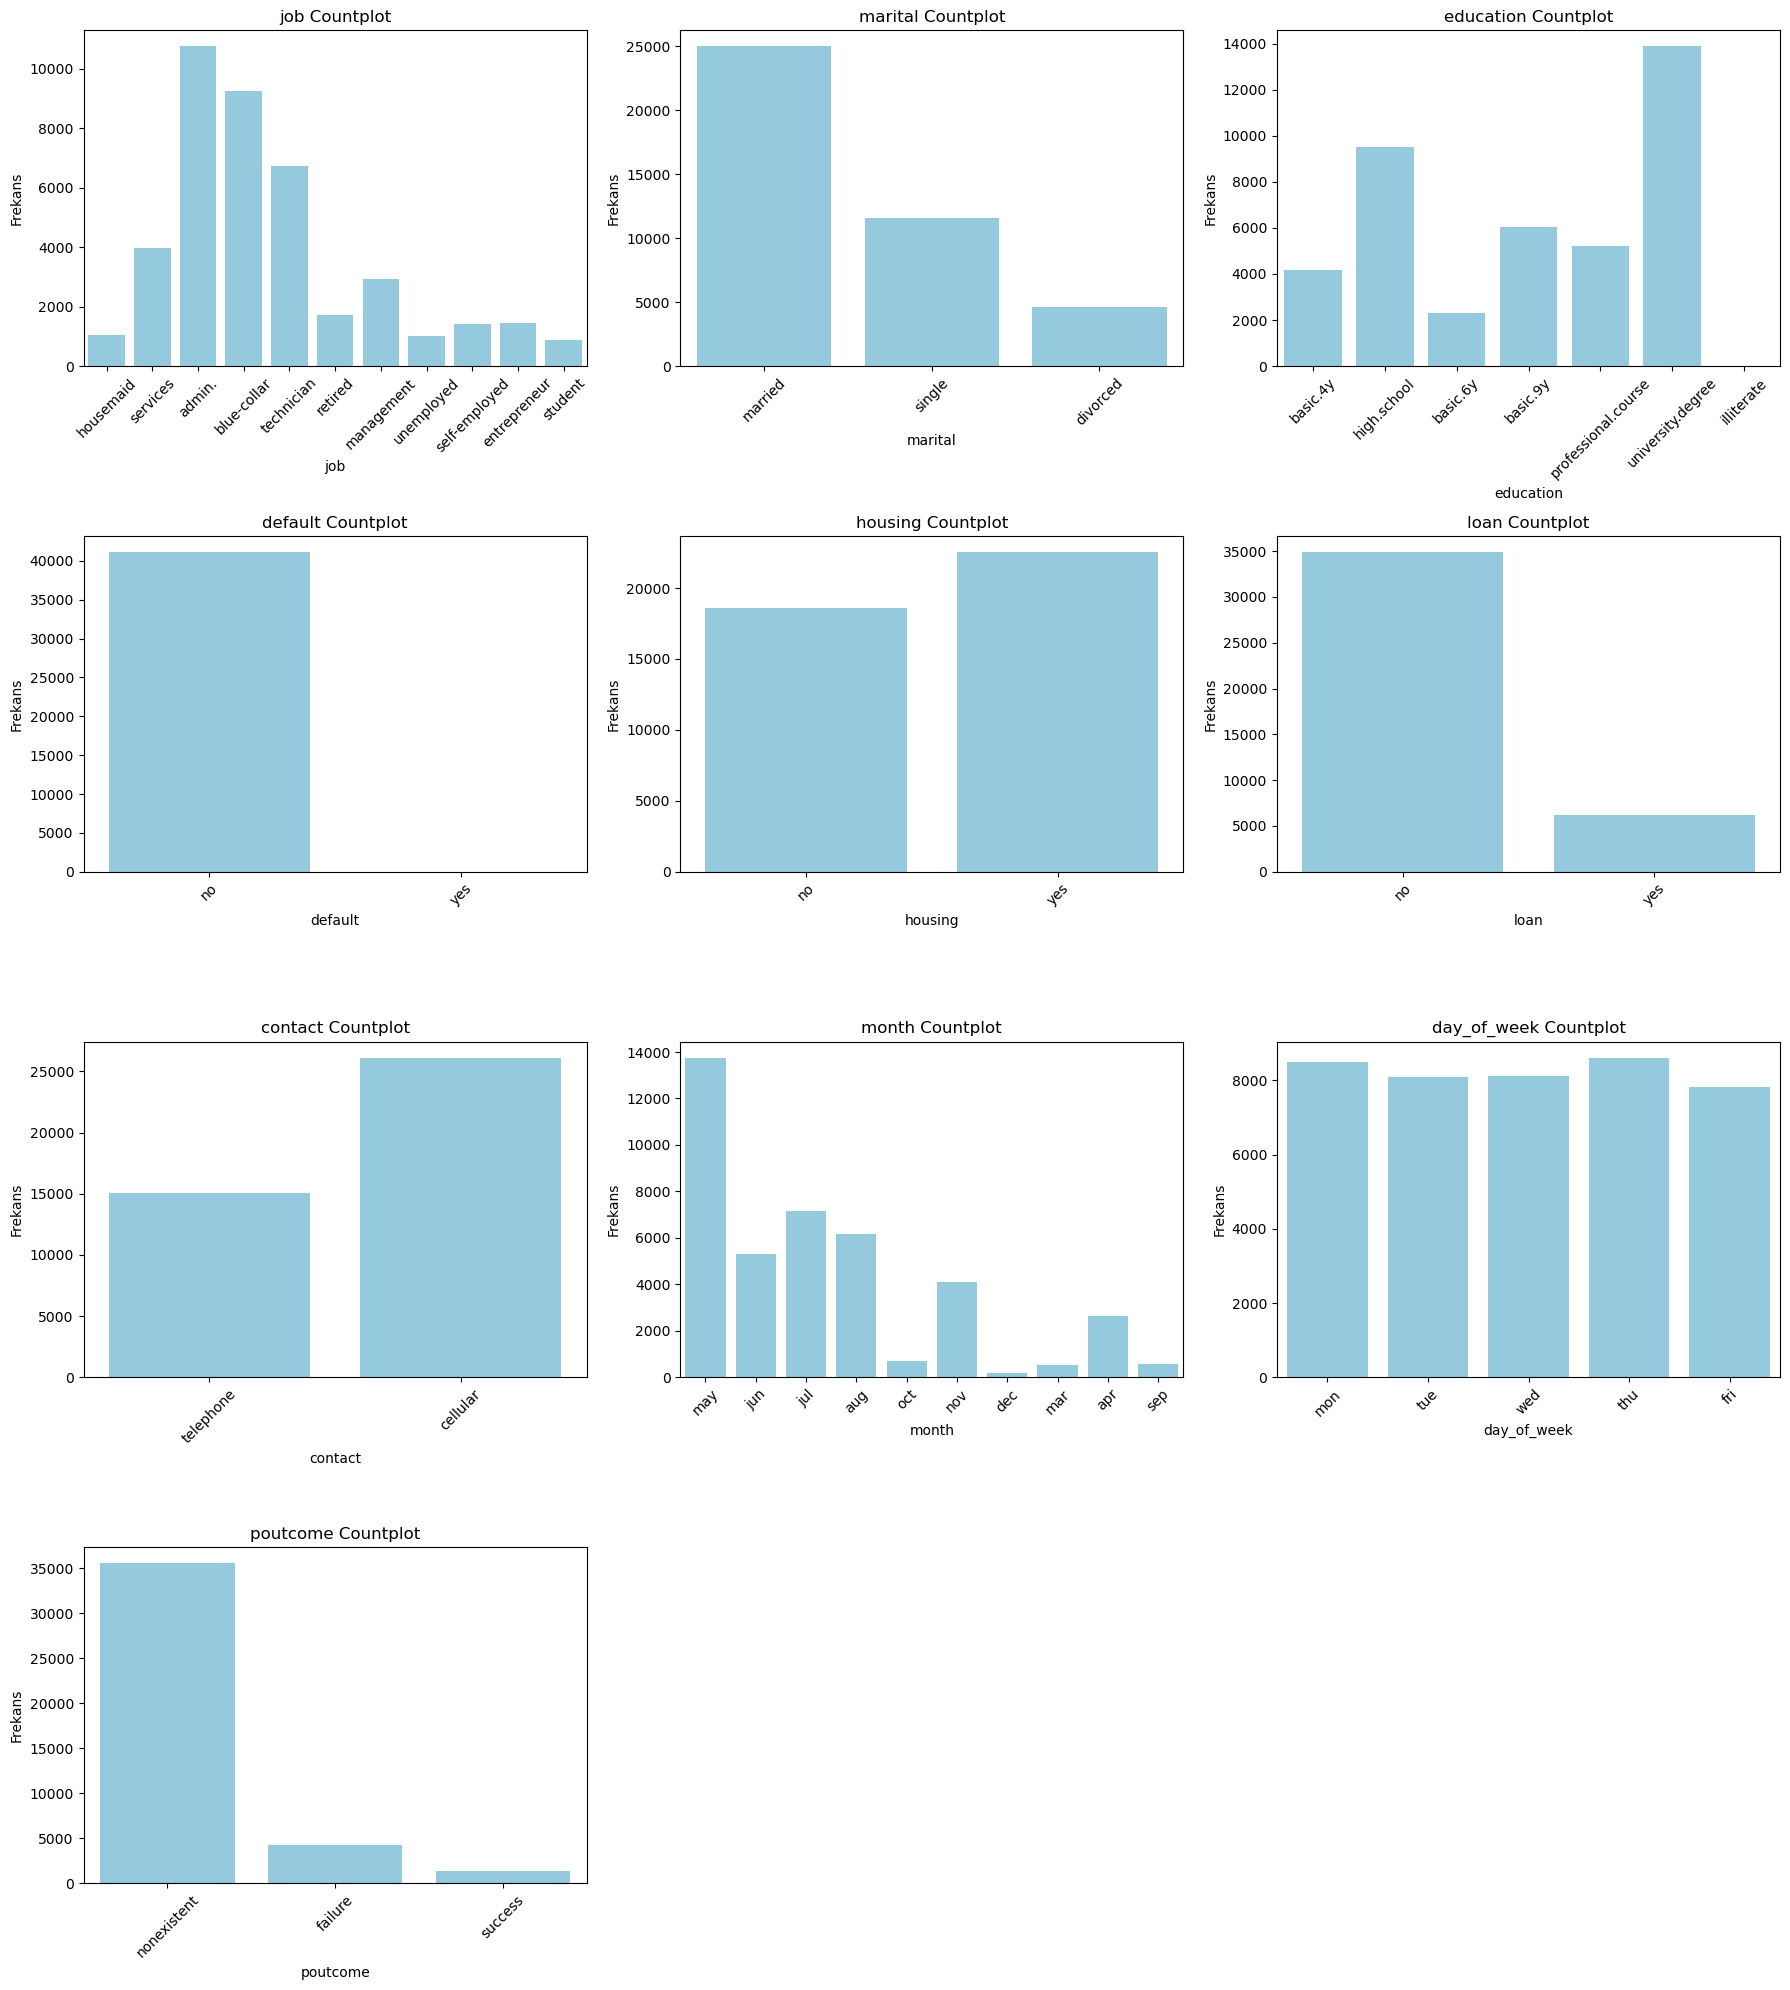

In [97]:
categorical_countplots(df)

### Encoding

In [98]:
from sklearn.model_selection import train_test_split

In [99]:
X = df.drop('y', axis = 1)
y = df['y']

In [100]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=36)

In [101]:
X_train.shape

(28808, 20)

In [102]:
X_test.shape

(12347, 20)

In [106]:
one_hot_cols = []
target_cols = []
for col in [col for col in df.columns if df[col].dtype == 'O']:
    if df[col].nunique() > 7 :
        target_cols.append(col)
    else:
        one_hot_cols.append(col)

In [107]:
one_hot_cols

['marital',
 'education',
 'default',
 'housing',
 'loan',
 'contact',
 'day_of_week',
 'poutcome']

In [108]:
target_cols

['job', 'month']

In [112]:
target_means_job = y_train.groupby(X_train['job']).mean()

In [113]:
target_means_job

job
admin.           0.128055
blue-collar      0.069061
entrepreneur     0.077154
housemaid        0.104139
management       0.111332
retired          0.254561
self-employed    0.103125
services         0.079281
student          0.326700
technician       0.108321
unemployed       0.143062
Name: y, dtype: float64

In [114]:
X_train['job_encoded'] = X_train['job'].map(target_means_job)
X_train['job_encoded'] = X_train['job_encoded'].fillna(y_train.mean())

X_test['job_encoded'] = X_test['job'].map(target_means_job)
X_test['job_encoded'] = X_test['job_encoded'].fillna(y_train.mean())

In [115]:
X_train.drop('job', axis=1, inplace=True)
X_test.drop('job', axis=1, inplace=True)

In [116]:
target_means_month = y_train.groupby(X_train['month']).mean()

In [117]:
target_means_month

month
apr    0.212836
aug    0.106882
dec    0.444444
jul    0.086816
jun    0.101430
mar    0.487179
may    0.063295
nov    0.103242
oct    0.442043
sep    0.471605
Name: y, dtype: float64

In [120]:
X_train['month_encoded'] = X_train['month'].map(target_means_month)
X_train['month_encoded'] = X_train['month_encoded'].fillna(y_train.mean())

X_test['month_encoded'] = X_test['month'].map(target_means_month)
X_test['month_encoded'] = X_test['month_encoded'].fillna(y_train.mean())

In [121]:
X_train.drop('month', axis=1, inplace=True)
X_test.drop('month', axis=1, inplace=True)

In [123]:
X_train.head()

,age,marital,education,default,housing,loan,contact,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,job_encoded,month_encoded
40786,41,married,high.school,no,no,no,cellular,wed,182,1,6,3,success,-1.1,94.199,-37.5,0.879,4963.6,0.143062,0.471605
5653,38,divorced,high.school,no,yes,no,telephone,mon,204,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0.104139,0.063295
23481,33,single,university.degree,no,yes,no,cellular,thu,131,11,999,0,nonexistent,1.4,93.444,-36.1,4.962,5228.1,0.108321,0.106882
35627,32,married,university.degree,no,yes,yes,cellular,mon,110,1,999,1,failure,-1.8,92.893,-46.2,1.244,5099.1,0.128055,0.063295
36801,22,single,high.school,no,yes,no,cellular,mon,147,1,999,0,nonexistent,-2.9,92.963,-40.8,1.260,5076.2,0.079281,0.101430


In [124]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [125]:
transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), one_hot_cols)
    ], remainder='passthrough'
)

In [126]:
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)

In [128]:
col_names = transformer.get_feature_names_out()

In [129]:
X_train = pd.DataFrame(X_train, columns=col_names)
X_test = pd.DataFrame(X_test, columns=col_names)

In [130]:
X_train.head()

,onehot__marital_married,onehot__marital_single,onehot__education_basic.6y,onehot__education_basic.9y,onehot__education_high.school,onehot__education_illiterate,onehot__education_professional.course,onehot__education_university.degree,onehot__default_yes,onehot__housing_yes,...,remainder__campaign,remainder__pdays,remainder__previous,remainder__emp.var.rate,remainder__cons.price.idx,remainder__cons.conf.idx,remainder__euribor3m,remainder__nr.employed,remainder__job_encoded,remainder__month_encoded
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,6.0,3.0,-1.1,94.199,-37.5,0.879,4963.6,0.143062,0.471605
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,999.0,0.0,1.1,93.994,-36.4,4.857,5191.0,0.104139,0.063295
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,11.0,999.0,0.0,1.4,93.444,-36.1,4.962,5228.1,0.108321,0.106882
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,999.0,1.0,-1.8,92.893,-46.2,1.244,5099.1,0.128055,0.063295
4,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,999.0,0.0,-2.9,92.963,-40.8,1.260,5076.2,0.079281,0.101430


In [131]:
X_test.head()

,onehot__marital_married,onehot__marital_single,onehot__education_basic.6y,onehot__education_basic.9y,onehot__education_high.school,onehot__education_illiterate,onehot__education_professional.course,onehot__education_university.degree,onehot__default_yes,onehot__housing_yes,...,remainder__campaign,remainder__pdays,remainder__previous,remainder__emp.var.rate,remainder__cons.price.idx,remainder__cons.conf.idx,remainder__euribor3m,remainder__nr.employed,remainder__job_encoded,remainder__month_encoded
0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,3.0,999.0,0.0,1.4,93.918,-42.7,4.963,5228.1,0.108321,0.086816
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,999.0,0.0,-0.1,93.200,-42.0,4.191,5195.8,0.128055,0.103242
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,2.0,999.0,0.0,1.1,93.994,-36.4,4.859,5191.0,0.069061,0.063295
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,1.0,999.0,0.0,-0.1,93.200,-42.0,4.076,5195.8,0.103125,0.103242
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,6.0,999.0,0.0,1.4,93.444,-36.1,4.967,5228.1,0.128055,0.106882


# Model Fitting

In [133]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [153]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [154]:
models = {
    'Logistic Regression' : LogisticRegression(class_weight= {0: 1, 1: 50}),
    'SVC' : SVC(),
    'KNN' : KNeighborsClassifier(),
    'Decision Tree' : DecisionTreeClassifier(class_weight='balanced'),
    'Random Forest Classifier' : RandomForestClassifier(class_weight='balanced'),
    'AdaBoost Classifier' : AdaBoostClassifier(),
    'GradientBoost Classifier' : GradientBoostingClassifier(),
    'XGBoost Classifier' : XGBClassifier(),
    'LightGBM Classifier' : LGBMClassifier()
}

In [155]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [156]:
def evaluate(true, pred):
    print(classification_report(true,pred))
    print(accuracy_score(true,pred))
    print(confusion_matrix(true,pred))

In [157]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    print(list(models.keys())[i], "results :\n")
    print("Train Results:")
    evaluate(y_train, y_pred_train)
    print("\nTest Results:")
    evaluate(y_test, y_pred_test)
    print("------------------------------------------------------")

Logistic Regression results :

Train Results:
              precision    recall  f1-score   support

           0       1.00      0.70      0.82     25578
           1       0.29      0.99      0.45      3230

    accuracy                           0.73     28808
   macro avg       0.65      0.84      0.64     28808
weighted avg       0.92      0.73      0.78     28808

0.7312552068869759
[[17882  7696]
 [   46  3184]]

Test Results:
              precision    recall  f1-score   support

           0       1.00      0.70      0.82     10948
           1       0.30      0.98      0.46      1399

    accuracy                           0.73     12347
   macro avg       0.65      0.84      0.64     12347
weighted avg       0.92      0.73      0.78     12347

0.734024459382846
[[7685 3263]
 [  21 1378]]
------------------------------------------------------
SVC results :

Train Results:
              precision    recall  f1-score   support

           0       0.94      0.98      0.96     25

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Classifier results :

Train Results:
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     25578
           1       0.67      0.39      0.49      3230

    accuracy                           0.91     28808
   macro avg       0.80      0.68      0.72     28808
weighted avg       0.90      0.91      0.90     28808

0.9099208553179672
[[24951   627]
 [ 1968  1262]]

Test Results:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     10948
           1       0.66      0.38      0.48      1399

    accuracy                           0.91     12347
   macro avg       0.79      0.68      0.71     12347
weighted avg       0.89      0.91      0.90     12347

0.9077508706568397
[[10682   266]
 [  873   526]]
------------------------------------------------------
GradientBoost Classifier results :

Train Results:
              precision    recall  f1-score   support

           0       0.95 

In [139]:
y_train.value_counts()

y
0    25578
1     3230
Name: count, dtype: int64

### Oversampling with XGBoost and LightGBM

In [159]:
# SMOTE = Syntethic Minority Oversampling Technique
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=36)
X_res, y_res = sm.fit_resample(X_train, y_train)

In [160]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_res, y_res)
    y_pred_train = model.predict(X_res)
    y_pred_test = model.predict(X_test)

    print(list(models.keys())[i], "results :\n")
    print("Train Results:")
    evaluate(y_res, y_pred_train)
    print("\nTest Results:")
    evaluate(y_test, y_pred_test)
    print("------------------------------------------------------")

Logistic Regression results :

Train Results:
              precision    recall  f1-score   support

           0       1.00      0.55      0.71     25578
           1       0.69      1.00      0.81     25578

    accuracy                           0.77     51156
   macro avg       0.84      0.77      0.76     51156
weighted avg       0.84      0.77      0.76     51156

0.7721088435374149
[[13949 11629]
 [   29 25549]]

Test Results:
              precision    recall  f1-score   support

           0       1.00      0.55      0.71     10948
           1       0.22      1.00      0.36      1399

    accuracy                           0.60     12347
   macro avg       0.61      0.77      0.53     12347
weighted avg       0.91      0.60      0.67     12347

0.5984449663885965
[[5996 4952]
 [   6 1393]]
------------------------------------------------------
SVC results :

Train Results:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     2

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost Classifier results :

Train Results:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91     25578
           1       0.91      0.92      0.92     25578

    accuracy                           0.91     51156
   macro avg       0.91      0.91      0.91     51156
weighted avg       0.91      0.91      0.91     51156

0.9148682461490343
[[23246  2332]
 [ 2023 23555]]

Test Results:
              precision    recall  f1-score   support

           0       0.96      0.91      0.94     10948
           1       0.51      0.74      0.61      1399

    accuracy                           0.89     12347
   macro avg       0.74      0.83      0.77     12347
weighted avg       0.91      0.89      0.90     12347

0.8913906212035312
[[9970  978]
 [ 363 1036]]
------------------------------------------------------
GradientBoost Classifier results :

Train Results:
              precision    recall  f1-score   support

           0       0.96     

In [161]:
n_pos = sum(y_train == 1)
n_neg = sum(y_train == 0)
scale = n_neg / n_pos

In [165]:
model = XGBClassifier(
    scale_pos_weight = scale,  # azınlık sınıfını ağırlıklandır
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_res, y_res)

C:\ProgramData\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [15:11:04] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [166]:
evaluate(y_test, model.predict(X_test))

              precision    recall  f1-score   support

           0       0.98      0.88      0.93     10948
           1       0.48      0.85      0.61      1399

    accuracy                           0.88     12347
   macro avg       0.73      0.87      0.77     12347
weighted avg       0.92      0.88      0.89     12347

0.8771361464323317
[[9640 1308]
 [ 209 1190]]
